In [1]:
import sympy as sp
import numpy as np

from composipy import OrthotropicMaterial, LaminateProperty, PlateStructure

In [2]:
E1 = 60800
E2 = 58250
v12 = 0.07
G12 = 4550
t = 0.21

mat_1 = OrthotropicMaterial(E1, E2, v12, G12, t)

In [3]:
from composipy import LaminateProperty
stacking = [-45, 45, 90, 0, 0, 0, 0, 90, 45, -45]
laminate1 = LaminateProperty(stacking, mat_1)

In [4]:
constraints = {    
    'x0' : ['TX', 'TY', 'TZ', 'RX', 'RY', 'RZ'],
    'xa' : ['TX', 'TY', 'TZ', 'RX', 'RY', 'RZ'],
    'y0' : ['TX', 'TY', 'TZ', 'RX', 'RY', 'RZ'],
    'yb' : ['TX', 'TY', 'TZ', 'RX', 'RY', 'RZ']
    }
panel = PlateStructure(laminate1, 360, 360, m=3, n=3, Nxx=-1, constraints=constraints)

In [5]:
panel.buckling_analysis()

(array([28.36588691, 34.48563012, 62.58303444, 80.15835116, 83.58601144]),
 array([[ 2.86437462e-14, -3.28112012e-14, -2.84745317e-14,
         -3.41863804e-15, -1.99990392e-15],
        [ 3.93061246e-17, -4.80494453e-18, -6.55021306e-17,
          8.92749325e-14, -4.39005984e-18],
        [-6.67973103e-14, -4.17868304e-15,  6.63981764e-14,
          7.97749733e-15,  4.99531746e-15],
        [ 8.60365863e-14,  5.36072967e-15, -8.42653685e-14,
          6.81238851e-15,  4.95577194e-15],
        [ 8.47966833e-15, -1.89596657e-17, -8.43584983e-15,
         -1.03287059e-15,  9.08738885e-13],
        [-1.83572892e-15,  1.79604123e-15, -4.86732011e-14,
         -1.15917035e-15,  1.61791837e-15],
        [ 6.54355566e-14,  2.51104949e-13, -6.50401384e-14,
         -7.81255340e-15, -6.10745631e-15],
        [-1.93467123e-14,  1.45953953e-15,  1.95406480e-14,
         -1.26644669e-12,  1.35534729e-15],
        [ 2.40441996e-14,  3.07643360e-14, -2.38859605e-14,
         -2.86703017e-15, -7.5799

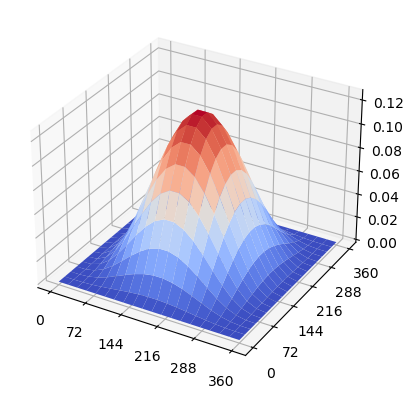

In [6]:
panel.plot_eigenvalue()

In [16]:
K, _ = panel.calc_K_KG()

In [18]:
K.shape

(27, 27)

In [17]:
sp.Matrix(K)

Matrix([
[     65.6375469509251,                     0,      -5.4726384112008,                     0,  1.00825817278934e-16,                     0,     -9.44498589582763,                     0,     0.663005524756819, -5.49959003339639e-17,                     0, -5.49959003339639e-17,                     0,      -2.3102935243505,                     0,   6.7494968591683e-17,                     0, -5.55514144787514e-19,                     0,  3.44679167023628e-19,                     0,  1.71623872975523e-14,                     0, -1.04053354460149e-15,                     0, -5.73452622379611e-20,                     0],
[                    0,      9.38329032317682,                     0, -1.00825817278934e-16,                     0,   2.7497950166982e-17,                     0,     -1.06567996630951,                     0,                     0,  1.28323767445916e-16,                     0,       2.3102935243505,                     0,    -0.630080052095591,                     0,

In [2]:
import sympy as sp

In [3]:
f1g1, f1g2, f2g1, f2g2 = sp.symbols(['f1g1', 'f1g2', 'f2g1', 'f2g2'])
af1g1, af1g2, af2g1, af2g2 = sp.symbols(['af1g1', 'af1g2', 'af2g1', 'af2g2'])
bf1g1, bf1g2, bf2g1, bf2g2 = sp.symbols(['bf1g1', 'bf1g2', 'bf2g1', 'bf2g2'])

In [8]:
u = sp.Matrix([[f1g1, f1g2, f2g1, f2g2]])
ua = sp.Matrix([[af1g1, af1g2, af2g1, af2g2]])
ub = sp.Matrix([[bf1g1, bf1g2, bf2g1, bf2g2]])


In [10]:
k_ex1 = u.T * u
k_ex1

Matrix([
[  f1g1**2, f1g1*f1g2, f1g1*f2g1, f1g1*f2g2],
[f1g1*f1g2,   f1g2**2, f1g2*f2g1, f1g2*f2g2],
[f1g1*f2g1, f1g2*f2g1,   f2g1**2, f2g1*f2g2],
[f1g1*f2g2, f1g2*f2g2, f2g1*f2g2,   f2g2**2]])

In [12]:
k_ex1.T == k_ex1 # check de simetria

True

In [7]:
u_values = f1g1 + f1g2 + f2g1 + f2g2
u_values**2

(f1g1 + f1g2 + f2g1 + f2g2)**2

In [21]:
k_ex2 = ua.T * ub
k_ex2

Matrix([
[af1g1*bf1g1, af1g1*bf1g2, af1g1*bf2g1, af1g1*bf2g2],
[af1g2*bf1g1, af1g2*bf1g2, af1g2*bf2g1, af1g2*bf2g2],
[af2g1*bf1g1, af2g1*bf1g2, af2g1*bf2g1, af2g1*bf2g2],
[af2g2*bf1g1, af2g2*bf1g2, af2g2*bf2g1, af2g2*bf2g2]])

In [22]:
k_ex2.T == k_ex2

False

In [19]:
k_ex3 = ua.T * ub + ub.T * ua
k_ex3

Matrix([
[            2*af1g1*bf1g1, af1g1*bf1g2 + af1g2*bf1g1, af1g1*bf2g1 + af2g1*bf1g1, af1g1*bf2g2 + af2g2*bf1g1],
[af1g1*bf1g2 + af1g2*bf1g1,             2*af1g2*bf1g2, af1g2*bf2g1 + af2g1*bf1g2, af1g2*bf2g2 + af2g2*bf1g2],
[af1g1*bf2g1 + af2g1*bf1g1, af1g2*bf2g1 + af2g1*bf1g2,             2*af2g1*bf2g1, af2g1*bf2g2 + af2g2*bf2g1],
[af1g1*bf2g2 + af2g2*bf1g1, af1g2*bf2g2 + af2g2*bf1g2, af2g1*bf2g2 + af2g2*bf2g1,             2*af2g2*bf2g2]])

In [20]:
k_ex3.T == k_ex3

True